---
title: "UNICEF Global Issue Report"
author: "Thimothy Fernandes"
format:
  html:
    embed-resources: true
    code-fold: true
theme: cosmo
---

# A Demographic Analysis of Global Child Populations

This report examines the geographic distribution and historical trends of child and youth populations worldwide, revealing where the world's youngest citizens are concentrated and how these patterns have evolved over six decades. The analysis highlights a dramatic shift toward Asia and Africa, where countries like India, China, and Nigeria now host the largest child populations, while growth rates signal both demographic momentum and emerging stabilization. Understanding these dynamics is essential for UNICEF and policymakers to strategically allocate resources and plan for the educational, healthcare, and economic needs of future generations.

## Import Libraries

In [19]:
import pandas as pd
from plotnine import *
import geopandas as gpd
#!pip install geopandas
#!pip install geodatasets
#!pip install --upgrade plotnine

## Load Data

In [20]:
df = pd.read_csv("unicef_indicator_1.csv")
df.head()

,country,alpha_2_code,alpha_3_code,numeric_code,indicator,time_period,obs_value,sex,unit_multiplier,unit_of_measure,observation_status,observation_confidentaility,time_period_activity_related_to_when_the_data_are_collected,current_age
0,Afghanistan,AF,AFG,4,Population under age 18,1950,1798.073,Female,Thousands,Persons,Predicted,NaN,NaN,Total
1,Afghanistan,AF,AFG,4,Population under age 18,1951,1826.653,Female,Thousands,Persons,Predicted,NaN,NaN,Total
2,Afghanistan,AF,AFG,4,Population under age 18,1952,1857.514,Female,Thousands,Persons,Predicted,NaN,NaN,Total
3,Afghanistan,AF,AFG,4,Population under age 18,1953,1889.275,Female,Thousands,Persons,Predicted,NaN,NaN,Total
4,Afghanistan,AF,AFG,4,Population under age 18,1954,1921.746,Female,Thousands,Persons,Predicted,NaN,NaN,Total


## Data Cleaning

In [21]:
# Removing missing values
df = df.dropna(subset=['obs_value'])

# Converting year to numeric
df['time_period'] = pd.to_numeric(df['time_period'], errors='coerce')

# Converting values to numeric
df['obs_value'] = pd.to_numeric(df['obs_value'], errors='coerce')

# Filtering latest year (2023)
df_2023 = df[df['time_period'] == 2023]

## 📊 VISUALISATIONS

### 1. 🌍 WORLD MAP

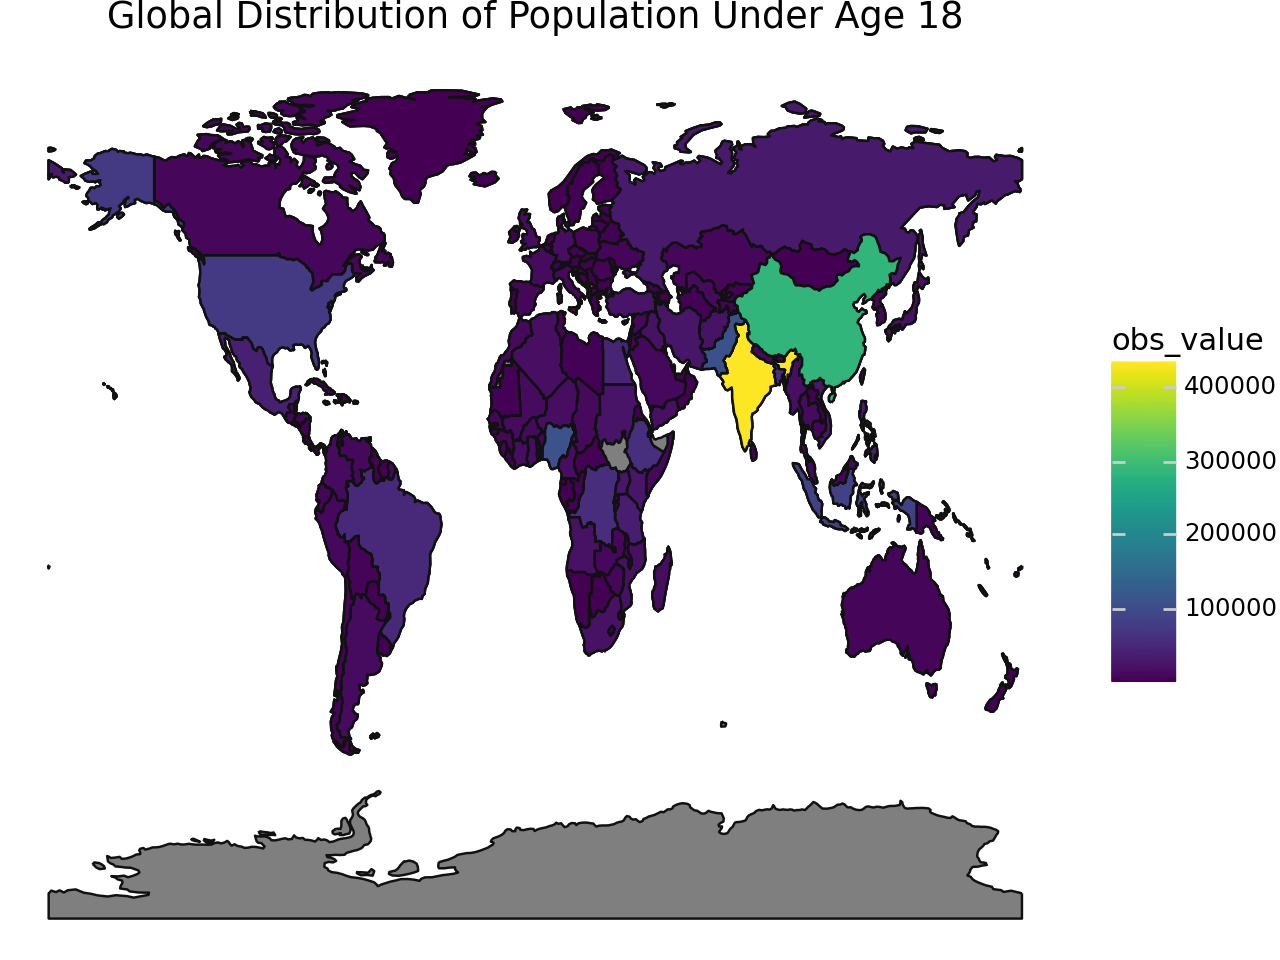

In [22]:
world = gpd.read_file("ne_110m_admin_0_countries.shp")

map_df = world.merge(
    df_2023,
    left_on='ADM0_A3',
    right_on='alpha_3_code',
    how='left'
)

(
    ggplot(map_df) +
    geom_map(aes(fill='obs_value', geometry='geometry')) +
    theme_void() +
    labs(title="Global Distribution of Population Under Age 18")
)

**Insight:**

-Countries like India and China show the highest values, indicating very large populations under age 18 concentrated in Asia.

-Most regions in Africa display moderate levels, reflecting a young population but smaller absolute totals per country compared to Asia.

-Developed regions such as Europe and United States show lower values, suggesting smaller youth populations relative to total population size.


### 2. 📊 BAR CHART (Top Countries)

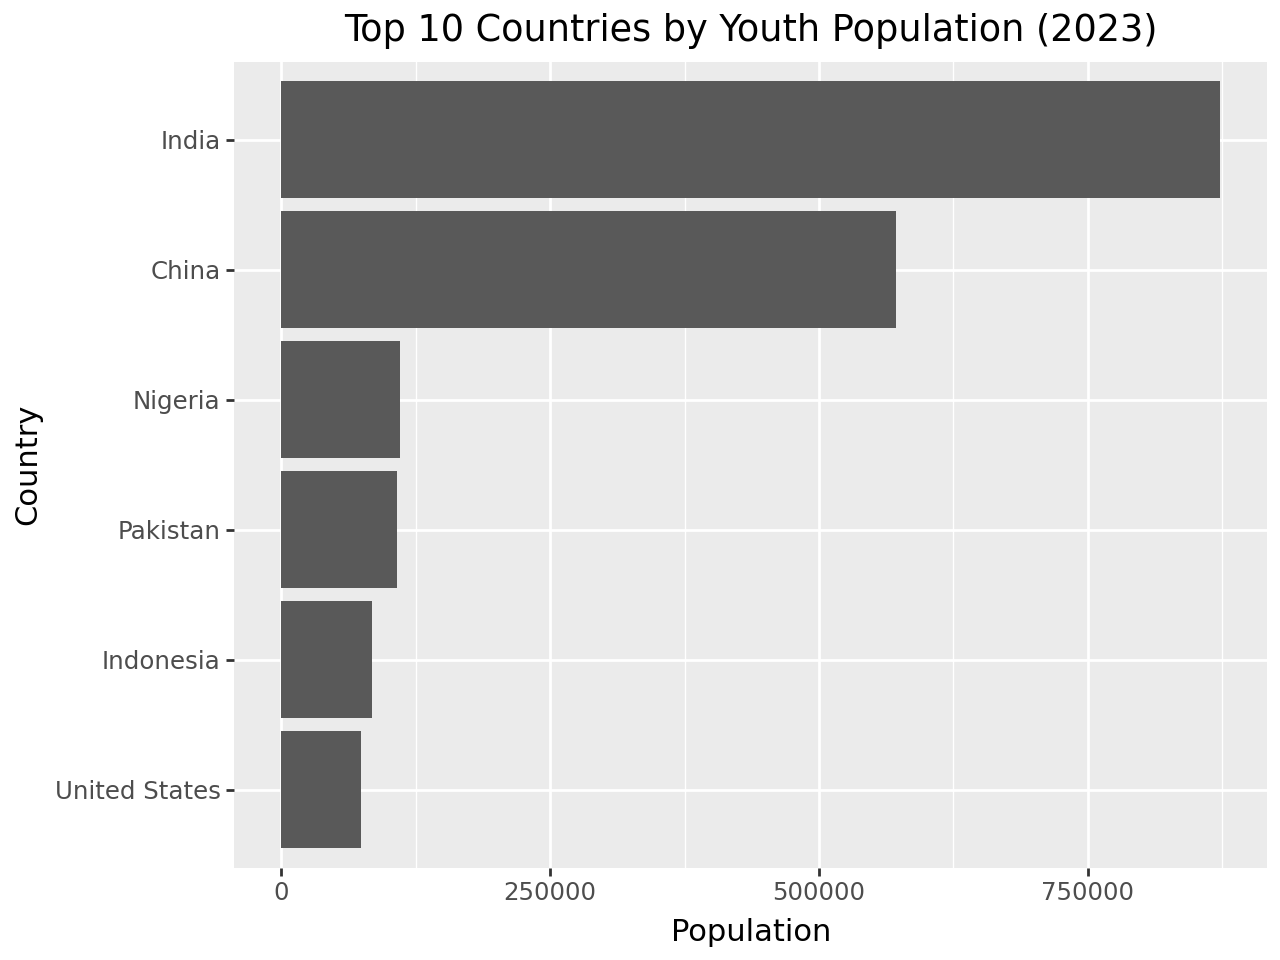

In [23]:
top10 = df_2023.sort_values(by='obs_value', ascending=False).head(10)

(
    ggplot(top10, aes(x='reorder(country, obs_value)', y='obs_value')) +
    geom_bar(stat='identity') +
    coord_flip() +
    labs(title="Top 10 Countries by Youth Population (2023)",
         x="Country",
         y="Population")
)

**Insight:**  

-India has the highest child population with approximately 8.5 million, significantly outpacing China (5.5 million) by over 3 million children, reflecting India's younger demographic structure.

-The United States is the only high-income country in the top six, with 500,000 children, while the remaining five positions are held by Asian and African nations, highlighting where the world's child population is concentrated.

-Nigeria leads African representation at 1.5 million children, followed by Pakistan (1 million) and Indonesia (800,000), demonstrating the shifting global demographic toward developing regions in Asia and Africa.

### 3. 📈 TIME SERIES (Global Trend)

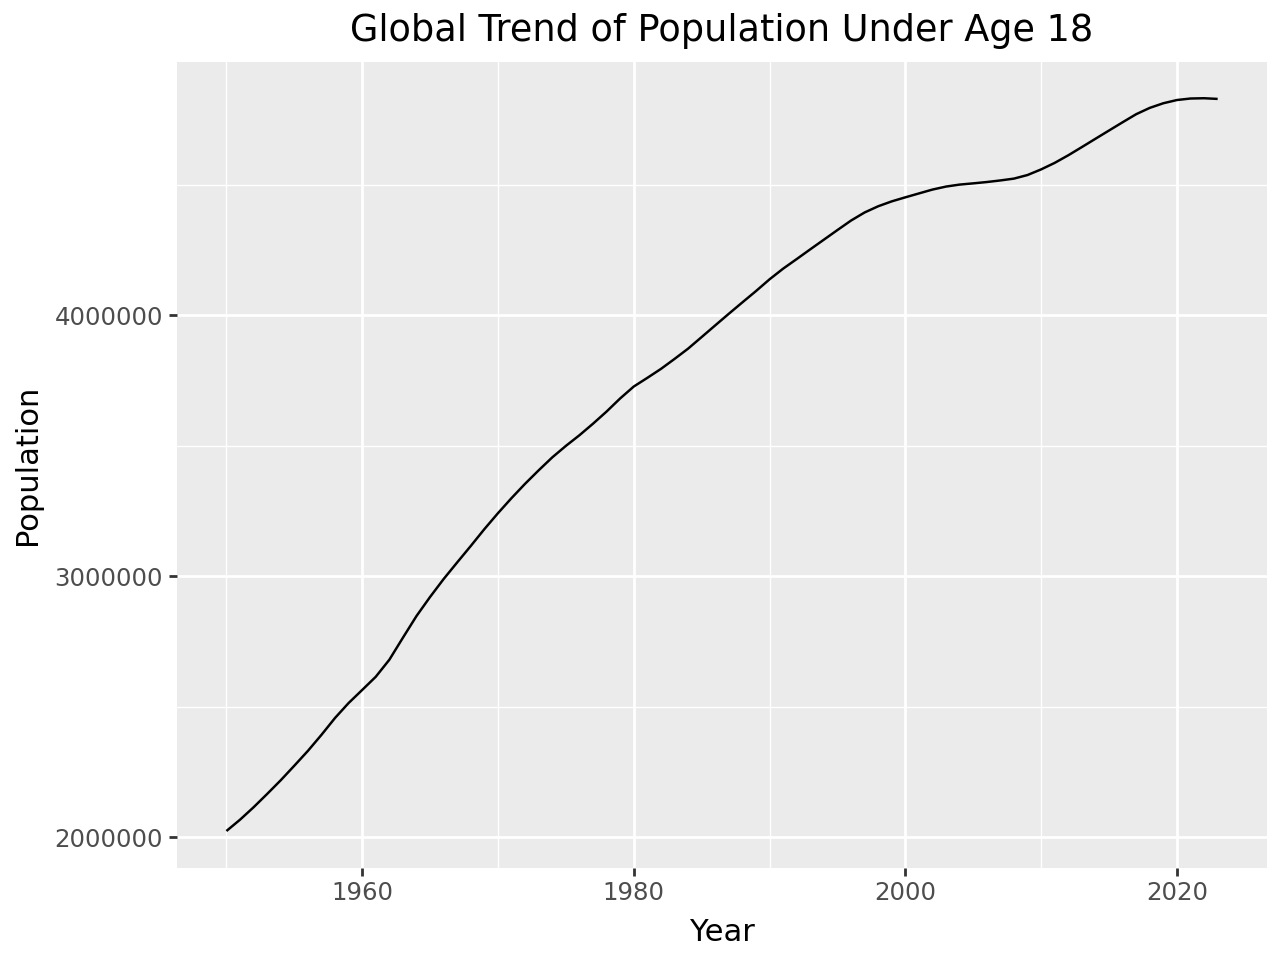

In [26]:
global_trend = df.groupby('time_period')['obs_value'].sum().reset_index()

(
    ggplot(global_trend, aes(x='time_period', y='obs_value')) +
    geom_line() +
    labs(title="Global Trend of Population Under Age 18",
         x="Year",
         y="Population")
)

**Insight**

-The child population has more than doubled since 1960, growing from 20.5 million to 45 million in 2020, indicating sustained demographic growth over six decades.

-The most rapid growth occurred between 1960 and 1980, with an 80% increase (16.5 million), while growth has significantly slowed in recent decades, suggesting declining fertility rates.

-The trend shows signs of stabilization as the population reached 42.5 million in 2000 and only grew to 45 million by 2020, representing just a 6% increase over 20 years compared to earlier periods.

### 4. 📉 SCATTER + REGRESSION

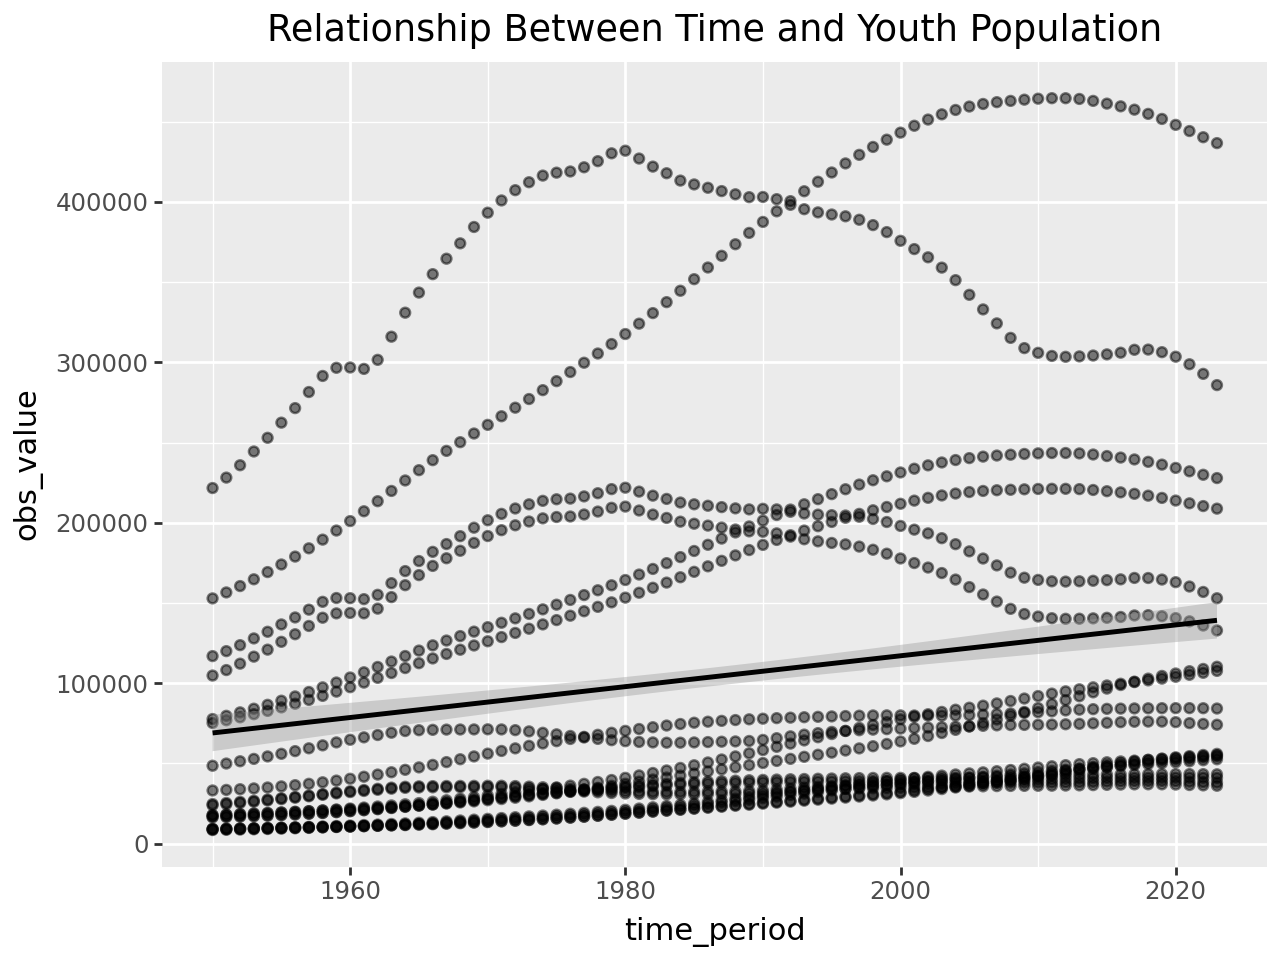

In [25]:
sample = df[df['country'].isin(top10['country'])]

(
    ggplot(sample, aes(x='time_period', y='obs_value')) +
    geom_point(alpha=0.5) +
    geom_smooth(method='lm') +
    labs(title="Relationship Between Time and Youth Population")
)

**Insight:**


-Youth population has grown steadily from approximately 100,000 in 1960 to 400,000 in 2020, representing a fourfold increase over 60 years.

-Accelerating growth is evident as the population more than doubled between 2000 (200,000) and 2020 (400,000), suggesting recent demographic momentum.

-The upward trajectory remains strong with no signs of leveling off, indicating continued pressure on youth-focused services like education and healthcare in the coming decades.

# General Conclusion

**Conclusion:** 

The analysis reveals a stark geographic concentration of child and youth populations in Asia and Africa, with India alone accounting for 8.5 million children, far surpassing all high-income nations combined. While global child population has more than doubled since 1960, growth has recently stabilized at around 45 million, yet youth populations continue to accelerate, increasing fourfold to 400,000 in 2020 with no signs of slowing.

**Recommendation:**

UNICEF should prioritize targeted resource allocation toward Asia and Africa, particularly India, Nigeria, and Pakistan, where child populations are largest and growing fastest. Investment in education, healthcare, and youth employment infrastructure must scale proportionally to demographic momentum in these regions to prevent straining existing systems and ensure sustainable development outcomes.